In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [3]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 1E87-BAE1

 Directory of C:\Users\casus\OneDrive\Desktop\AERO ORGANISED\MY WORK, PROJECTS ETC\RESEARCH & PATENTS\ANUP SIR\Optimising_conference_data

07/10/2025  15:19    <DIR>          .
07/10/2025  14:33    <DIR>          ..
07/10/2025  14:36    <DIR>          .ipynb_checkpoints
07/10/2025  14:33            16,685 CL & CD Graphs of Injection & Suction.xlsx
07/10/2025  15:00               941 conference_injection_only.csv
07/10/2025  15:16               941 conference_suction_only.csv
07/10/2025  15:06            14,539 injection_only.csv
07/10/2025  14:38               617 Optimising_conference_work.ipynb
06/10/2025  11:09           457,665 Performance_improvement_of_horizontal_axis_wind_turbine_using_active_control_methods.pdf
07/10/2025  15:19            14,972 suction_only.csv
               7 File(s)        506,360 bytes
               3 Dir(s)  190,766,604,288 bytes free


In [2]:
suction_df = pd.read_csv('./suction_only.csv')
suction_df.columns = ['AOA', 'suction_location', 'suction_slot_size', 'cl', 'cd', 'Re', 'chord_length']
suction_df

,AOA,suction_location,suction_slot_size,cl,cd,Re,chord_length
0,-20.0,53,0.5,-0.65,0.280,1000000,460
1,-19.5,53,0.5,-0.66,0.265,1000000,460
2,-19.0,53,0.5,-0.67,0.250,1000000,460
3,-18.5,53,0.5,-0.68,0.235,1000000,460
4,-18.0,53,0.5,-0.69,0.220,1000000,460
...,...,...,...,...,...,...,...
679,25.5,50,2.0,3.50,0.864,2000000,600
680,26.0,50,2.0,3.45,0.888,2000000,600
681,26.5,50,2.0,3.40,0.912,2000000,600
682,27.0,50,2.0,3.35,0.936,2000000,600


In [3]:
# setting up the data
data_df = suction_df.drop(columns=['cl', 'cd'])
data_df
suction_data = np.array(data_df)
suction_data

array([[-2.00e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       [-1.95e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       [-1.90e+01,  5.30e+01,  5.00e-01,  1.00e+06,  4.60e+02],
       ...,
       [ 2.65e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02],
       [ 2.70e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02],
       [ 2.75e+01,  5.00e+01,  2.00e+00,  2.00e+06,  6.00e+02]],
      shape=(684, 5))

In [5]:
#setting up the targets
suction_cl = np.array(suction_df['cl'])
suction_cd = np.array(suction_df['cd'])
# injection_cl

In [6]:
# splitting the data for cl and and cd separately
from sklearn.model_selection import train_test_split

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(suction_data, suction_cl, random_state=0)
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(suction_data, suction_cd, random_state=0)

# X_train_cd
# X_train_cl

### Data Scaling

In [7]:
# scaling the data
from sklearn.preprocessing import StandardScaler

scaler_cl = StandardScaler().fit(X_train_cl)
scaler_cd = StandardScaler().fit(X_train_cd)
# scaling the cl data

X_train_cl_scaled = scaler_cl.transform(X_train_cl)
X_test_cl_scaled = scaler_cl.transform(X_test_cd)

# scaling the cd data
X_train_cd_scaled = scaler_cd.transform(X_train_cd)
X_test_cd_scaled = scaler_cd.transform(X_test_cd)

# X_train_cd_scaled
# X_train_cl_scaled


### Training the models

In [10]:
from sklearn.neural_network import MLPRegressor

mlp_cl = MLPRegressor(random_state=0, early_stopping=True, max_iter=400).fit(X_train_cl_scaled, y_train_cl)

mlp_cd = MLPRegressor(random_state=0, early_stopping=True, hidden_layer_sizes=(100, 75), max_iter=250).fit(X_train_cd_scaled, y_train_cd)

print("CL prediction accuracy")
print(f"Cl training score: {mlp_cl.score(X_train_cl_scaled, y_train_cl)}")
print(f"Cl Test score: {mlp_cl.score(X_test_cl_scaled, y_test_cl)}")


print("\nCD prediction accuracy")
print(f"Cd training score: {mlp_cd.score(X_train_cd_scaled, y_train_cd)}")
print(f"Cd Test score: {mlp_cd.score(X_test_cd_scaled, y_test_cd)}")



CL prediction accuracy
Cl training score: 0.9964096718847674
Cl Test score: 0.9969876115381259

CD prediction accuracy
Cd training score: 0.9981949634154719
Cd Test score: 0.9972462882130796


###  Optimising CL

In [30]:
angles = np.arange(0, 28, 1)
# angles = np.arange(0, 5, 1)
# angles
optimised_cl_values = []
optimised_suction_locations= []
optimised_suction_slot_sizes= []
optimised_Re_values= []
optimised_chord_length_values= []

In [31]:
import skopt
from skopt.optimizer import gp_minimize
from skopt.space import Real, Integer, Categorical

for angle in angles:
    print(f'optimising for {angle} deg', end=',')
    def objective_function_cl(params):
        aoa = angle
        suction_location, suction_slot_size, Re, chord_length  = params
        X_input = [[aoa, suction_location, suction_slot_size, Re, chord_length]]
        X_input_scaled = scaler_cl.transform(X_input)
        predicted_cl = mlp_cl.predict(X_input_scaled)


        return -predicted_cl[0]

    space = [
        Integer(50, 80, name='suction_location'),
        Real(0.5, 2, name='suction_slot_size'),
        Integer(1000000, 2000000, name='Re'),
        Integer(460, 600, name='chord_length')    
    ]

    result = gp_minimize(
        func=objective_function_cl,
        dimensions=space,
        n_calls = 30,
        random_state = 0
    )
    optimised_cl_values.append(-result.fun)
    optimised_suction_locations.append(result.x[0])
    optimised_suction_slot_sizes.append(result.x[1])
    optimised_Re_values.append(result.x[2])
    optimised_chord_length_values.append(result.x[3])

    print(f' {angle} done!')
    

optimising for 0 deg, 0 done!
optimising for 1 deg, 1 done!
optimising for 2 deg, 2 done!
optimising for 3 deg, 3 done!
optimising for 4 deg, 4 done!
optimising for 5 deg, 5 done!
optimising for 6 deg, 6 done!
optimising for 7 deg, 7 done!
optimising for 8 deg, 8 done!
optimising for 9 deg, 9 done!
optimising for 10 deg, 10 done!
optimising for 11 deg, 11 done!
optimising for 12 deg, 12 done!
optimising for 13 deg, 13 done!
optimising for 14 deg, 14 done!
optimising for 15 deg, 15 done!
optimising for 16 deg, 16 done!
optimising for 17 deg,

C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(70), 1.511930645888936, np.int64(1540631), np.int64(461)]
  warnings.warn(


 17 done!
optimising for 18 deg, 18 done!
optimising for 19 deg, 19 done!
optimising for 20 deg, 20 done!
optimising for 21 deg, 21 done!
optimising for 22 deg, 22 done!
optimising for 23 deg, 23 done!
optimising for 24 deg, 24 done!
optimising for 25 deg, 25 done!
optimising for 26 deg, 26 done!
optimising for 27 deg, 27 done!


In [32]:
output_dict = {
    'aoa' : angles,
    'optimised_cl' : optimised_cl_values,
    'optimal_suction_loc' : optimised_suction_locations,
    'optimal_suction_slot_size' : optimised_suction_slot_sizes,
    're_values' : optimised_Re_values,
    'chord_length' : optimised_chord_length_values
}
output_df = pd.DataFrame(output_dict)
output_df
# -result.fun

,aoa,optimised_cl,optimal_suction_loc,optimal_suction_slot_size,re_values,chord_length
0,0,2.001703,50,2.0,1000000,600
1,1,2.045374,50,2.0,1000000,600
2,2,2.089044,50,2.0,1000000,600
3,3,2.132714,50,2.0,1000000,600
4,4,2.177011,50,2.0,1000000,600
5,5,2.221997,50,2.0,1000000,600
6,6,2.266982,50,2.0,1000000,600
7,7,2.311967,50,2.0,1000000,600
8,8,2.356953,50,2.0,1000000,600
9,9,2.401938,50,2.0,1000000,600


In [21]:
output_df.to_csv('suction_optimised.csv')

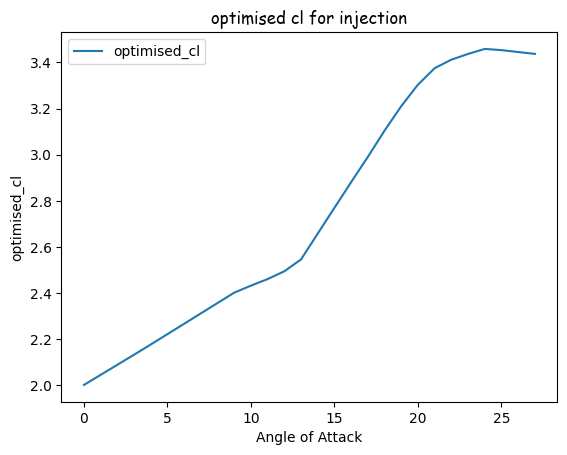

In [33]:
plt.plot(angles, optimised_cl_values, label='optimised_cl')

plt.title("optimised cl for injection", fontname="Comic Sans MS")
plt.xlabel("Angle of Attack"),
plt.ylabel("optimised_cl")
plt.legend()
plt.show()

## Stabilising the CL value -- The everything script

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# importing and creating the data
suction_df = pd.read_csv('./suction_only.csv')
suction_df.columns = ['AOA', 'suction_location', 'suction_slot_size', 'cl', 'cd', 'Re', 'chord_length']
data_df = suction_df.drop(columns=['cl', 'cd'])
suction_data = np.array(data_df)

#setting up the targets
suction_cl = np.array(suction_df['cl'])
suction_cd = np.array(suction_df['cd'])

# splitting the data for cl and and cd separately
from sklearn.model_selection import train_test_split

X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(suction_data, suction_cl, random_state=0)
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(suction_data, suction_cd, random_state=0)

# scaling the data
from sklearn.preprocessing import StandardScaler

scaler_cl = StandardScaler().fit(X_train_cl)
scaler_cd = StandardScaler().fit(X_train_cd)
# scaling the cl data

X_train_cl_scaled = scaler_cl.transform(X_train_cl)
X_test_cl_scaled = scaler_cl.transform(X_test_cd)

# scaling the cd data
X_train_cd_scaled = scaler_cd.transform(X_train_cd)
X_test_cd_scaled = scaler_cd.transform(X_test_cd)

# declaring the ranges
angles = np.arange(0, 28, 1)
# angles = np.arange(0, 5, 1)
# angles
random_states = np.arange(1, 5, 1)
optimised_cl_values = []
optimised_suction_locations= []
optimised_suction_slot_sizes= []
optimised_Re_values= []
optimised_chord_length_values= []

# optmising and stabilising
import skopt
from skopt.optimizer import gp_minimize
from skopt.space import Real, Integer, Categorical

for angle in angles:
    print(f'..........optimising for {angle} deg.......')
    for state in random_states: 
        print(f"state {state}", end=',')
        optimised_cl_per_state = []
        optimised_suction_location_per_state = []
        optimised_suction_slot_size_per_state = []
        optimised_Re_per_state = []
        optimised_chord_length_per_state = []

        def objective_function_cl(params):
            # set aoa
            aoa = angle
            # receive other parameters from optimiser
            suction_location, suction_slot_size, Re, chord_length  = params
            # scale the data to pred for training
            X_input = [[aoa, suction_location, suction_slot_size, Re, chord_length]]
            X_input_scaled = scaler_cl.transform(X_input)
            
            # train the model for that specific random_state
            mlp_cl = MLPRegressor(random_state=state, early_stopping=True, max_iter=400).fit(X_train_cl_scaled, y_train_cl)
            predicted_cl = mlp_cl.predict(X_input_scaled)
    
    
            return -predicted_cl[0]
    
        space = [
            Integer(50, 80, name='suction_location'),
            Real(0.5, 2, name='suction_slot_size'),
            Integer(1000000, 2000000, name='Re'),
            Integer(460, 600, name='chord_length')    
        ]
    
        result = gp_minimize(
            func=objective_function_cl,
            dimensions=space,
            n_calls = 30,
            random_state = 0
        )
        optimised_cl_per_state.append(-result.fun)
        optimised_suction_location_per_state.append(result.x[0])
        optimised_suction_slot_size_per_state.append(result.x[1])
        optimised_Re_per_state.append(result.x[2])
        optimised_chord_length_per_state.append(result.x[3])
        print(f"{state} done!", end=',')
        
    
    optimised_cl_values.append(float(np.mean(optimised_cl_per_state)))
    optimised_suction_locations.append(float(np.mean(optimised_suction_location_per_state)))
    optimised_suction_slot_sizes.append(float(np.mean(optimised_suction_slot_size_per_state)))
    optimised_Re_values.append(float(np.mean(optimised_Re_per_state)))
    optimised_chord_length_values.append(float(np.mean(optimised_chord_length_per_state)))

    print(f'\n {angle} done!')
    

..........optimising for 0 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 0 done!
..........optimising for 1 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 1 done!
..........optimising for 2 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 2 done!
..........optimising for 3 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 3 done!
..........optimising for 4 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 4 done!
..........optimising for 5 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,4 done!,
 5 done!
..........optimising for 6 deg.......
state 1,1 done!,state 2,

C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(70), 1.511930645888936, np.int64(1540631), np.int64(461)]
  warnings.warn(


2 done!,state 3,3 done!,state 4,4 done!,
 6 done!
..........optimising for 7 deg.......
state 1,1 done!,state 2,2 done!,state 3,3 done!,state 4,

C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(70), 1.511930645888936, np.int64(1540631), np.int64(461)]
  warnings.warn(


4 done!,
 7 done!
..........optimising for 8 deg.......
state 1,

...

4 done!,
 25 done!
..........optimising for 26 deg.......
state 1,1 done!,state 2,2 done!,state 3,

C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(71), 1.1390582771676339, np.int64(1618376), np.int64(542)]
  warnings.warn(
C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(71), 1.536876187453724, np.int64(1617959), np.int64(505)]
  warnings.warn(
C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(63), 0.9658173721183454, np.int64(1086888), np.int64(599)]
  warnings.warn(
C:\Users\casus

3 done!,state 4,4 done!,
 26 done!
..........optimising for 27 deg.......
state 1,1 done!,state 2,2 done!,state 3,

C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(71), 1.1390582771676339, np.int64(1618376), np.int64(542)]
  warnings.warn(
C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(71), 1.536876187453724, np.int64(1617959), np.int64(505)]
  warnings.warn(
C:\Users\casus\AppData\Local\Programs\Python\Python313\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(50), 2.0, np.int64(2000000), np.int64(600)] before, using random point [np.int64(63), 0.9658173721183454, np.int64(1086888), np.int64(599)]
  warnings.warn(


3 done!,state 4,4 done!,
 27 done!


In [42]:
output_dict_stable = {
    'aoa' : angles,
    'optimised_cl' : optimised_cl_values,
    'optimal_suction_loc' : optimised_suction_locations,
    'optimal_suction_slot_size' : optimised_suction_slot_sizes,
    're_values' : optimised_Re_values,
    'chord_length' : optimised_chord_length_values
}
output_df_stable = pd.DataFrame(output_dict_stable)
output_df_stable

,aoa,optimised_cl,optimal_suction_loc,optimal_suction_slot_size,re_values,chord_length
0,0,1.092102,50.0,2.0,1000000.0,460.0
1,1,1.166652,50.0,2.0,1000000.0,460.0
2,2,1.232999,50.0,2.0,1000000.0,460.0
3,3,1.291498,50.0,2.0,1000000.0,460.0
4,4,1.349074,50.0,2.0,1000000.0,460.0
5,5,1.411390,50.0,2.0,2000000.0,600.0
6,6,1.542077,50.0,2.0,2000000.0,600.0
7,7,1.672764,50.0,2.0,2000000.0,600.0
8,8,1.803452,50.0,2.0,2000000.0,600.0
9,9,1.934139,50.0,2.0,2000000.0,600.0


In [45]:
output_df_stable.to_csv('suction_optimised_stable.csv')